# He plasma

- 2022.09.03    u.k., k.i. 
- 2022.09.10    k.i., t.k.   include plasma measurement 
- 2023.04.01    k.i., u.k.   ion temperature and fixed ionization ratio 


In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import numpy as np

#%matplotlib inline
#%matplotlib qt
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%load_ext autoreload
%autoreload 2

from spectra.ImportAll import *
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', DeprecationWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from spectra.Struct import Atom, Atmosphere, Radiation
from spectra.Atomic import Collision, SEsolver, ContinuumOpacity, BasicP
from spectra.Util import HelpUtil
from spectra.Visual import Plotting  #, Grotrian
from spectra.Atomic import LTELib
from spectra.Function.SEquil import SELib
#from spectra.Function.Icp import SELib    # T_e != T_i for ICP

from spectra.Atomic import Hydrogen
from spectra.Util.AtomUtils.AtomInfo import level_info, extract_lprof, each_prof, line_list
from spectra import Constants as Cst
from spectra.Function.SlabModel import CloudModel

## Create atomic model

In [5]:
# Atomic model
import os

conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/He.conf" )
atom_He, wMesh_He, path_dict_He = Atom.init_Atom_(conf_path , is_hydrogen=False)
HelpUtil.help_( atom_He )
path_dict_He

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Atom
|- Z                       int                                  v: 2
|- Mass                    float                                v: 4.0026
|- Abun                    float                                v: 0.09772372209558111
|- nLevel                  int                                  v: 27
|- nLine                   int                                  v: 205
|- nCont                   int                                  v: 26
|- nTran                   int                                  v: 231
|- nRL                     int                                  v: 39
|- Level                   struct array                         s: (27,)
  |-  erg                  float64                              s: (27,)
  |- 

{'folder': 'C:\\home\\python\\spectra\\data\\atom\\He',
 'conf': 'C:\\home\\Python\\spectra\\data\\conf\\He.conf',
 'Level': 'C:\\home\\python\\spectra\\data\\atom\\He\\He.Level',
 'Aji': 'C:\\home\\python\\spectra\\data\\atom\\He\\He.Aji',
 'CEe': 'C:\\home\\python\\spectra\\data\\atom\\He\\He.CE.electron',
 'CIe': 'C:\\home\\python\\spectra\\data\\atom\\He\\He.CI.electron',
 'PI': 'C:\\home\\python\\spectra\\data\\atom\\He\\He.Alpha',
 'RadiativeLine': 'C:\\home\\python\\spectra\\data\\atom\\He\\He.RadiativeLine',
 'Grotrian': 'C:\\home\\python\\spectra\\data\\atom\\He\\He.Grotrian'}

## He Plasma observation

dict_keys(['wl', 'pr', 'sp50w'])


array([0.4, 0.5, 1. , 2. , 3. , 4. , 5.3], dtype=float32)

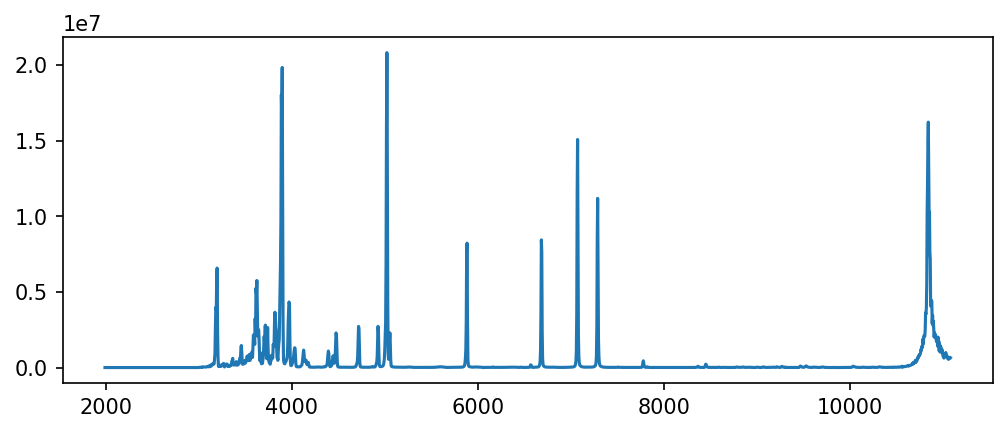

In [7]:
import scipy.io as sio

filename = 'C:\data\hida\plasma/sp50w_pscan.sav'   # data on 2022.09.02
d = sio.readsav(filename)
#print(d.date_obs)
print(d.keys())

wlo = d.wl[0:2048] *10    # nm
spo = d.sp50w[2,:]  # W/m^2/nm
# W/m^2/nm  -> erg/cm^3/s/str
spo = spo *10**7 / 10.**4 *10.**7

fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)
ax.plot(wlo,spo,label='He')

d.pr

In [8]:
# from spectra.Function.SlabModel import CloudModel
Te = 5E4
Ti = -1
Pg_pa = 5  # [Pa]
Pg = Pg_pa * 10 # [dyn/cm^2, cgs]
Nh = 1*1e11
Ne = 1e10
Vd = 0.
Vt = 0.            #   cm/s
depth = 20. # cm   6.E3 * 1.E5 #   km *1e5
stage_pop = np.array([1.,1e-5, 1e-10])  # set to 0 will cause NAN value in solving equation Ax=b

#slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
slab = Atmosphere.Atmosphere0D(Nh=0.0, Ne=0.0, Te=Te, Vd=Vd, Vt=Vt, Pg=Pg, Ti=Ti)
radiation = Radiation.init_Radiation_(slab, wMesh_He)
radiation.backRad[1,:] = 0.0     # no incident intensity for b-b transition
radiation.PI_intensity[:,:] = 0    #  no incident intensity for b-f transition

#SE_He, Rate_He = SELib.cal_SE_with_Nh_Te_(atom_He, slab, wMesh_He, solar_spec_He, None) # SE_H.n_SE)  #  level populations etc.
SE_He, Rate_He = SELib.cal_SE_with_Pg_Te_single_Atom_(atom_He, slab, wMesh_He, radiation)#, stage_pop)

lHe = CloudModel.SE_to_slab_0D_(atom_He, slab, SE_He, depth=depth)      # hydrogen lines intensity


Ne2Ng=1.000E-01  Ng=6.585E+12  Ne=6.585E+11
Ne2Ng=9.976E-01  Ng=3.626E+12  Ne=3.613E+12


C:\home\Python\spectra\spectra\Function\SlabModel\CloudModel.py:47: RuntimeWarning: invalid value encountered in divide
  Src   : T_ARRAY = ( Aji * nj ) / ( Bij * ni - Bji * nj )


In [9]:
slab.Ne

3615361217211.2354

In [10]:
# check result population 
for i in range(3):
    res = (SE_He.n_SE * (atom_He.Level['stage']==i+1)).sum()
    print(f"sum of the population of stage {i+1} = {res}")

SE_He.n_SE

sum of the population of stage 1 = 0.002693105083108315
sum of the population of stage 2 = 0.9969962285741895
sum of the population of stage 3 = 0.00031066634270209025


array([2.69199323e-03, 4.61752154e-07, 2.34634025e-07, 2.06071887e-07,
       1.23642861e-07, 4.12131504e-08, 2.31981575e-09, 5.95620797e-09,
       4.51728231e-09, 7.10101068e-09, 3.76092861e-09, 2.68637739e-09,
       1.61182447e-09, 2.68697191e-09, 1.27778934e-09, 1.60138115e-09,
       5.83610642e-10, 3.58528171e-09, 5.13625566e-09, 1.71205887e-09,
       9.96996227e-01, 1.09119656e-09, 5.59361862e-10, 4.89794442e-11,
       5.88079220e-11, 1.70386595e-10, 3.10666343e-04])

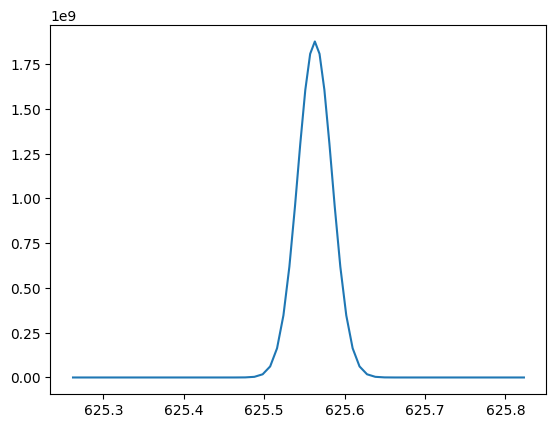

In [11]:
# to check line width
plt.plot(SE_He.wave_mesh_shifted_1d[0:40]*1E8, SE_He.absorb_prof_1d[0:40])

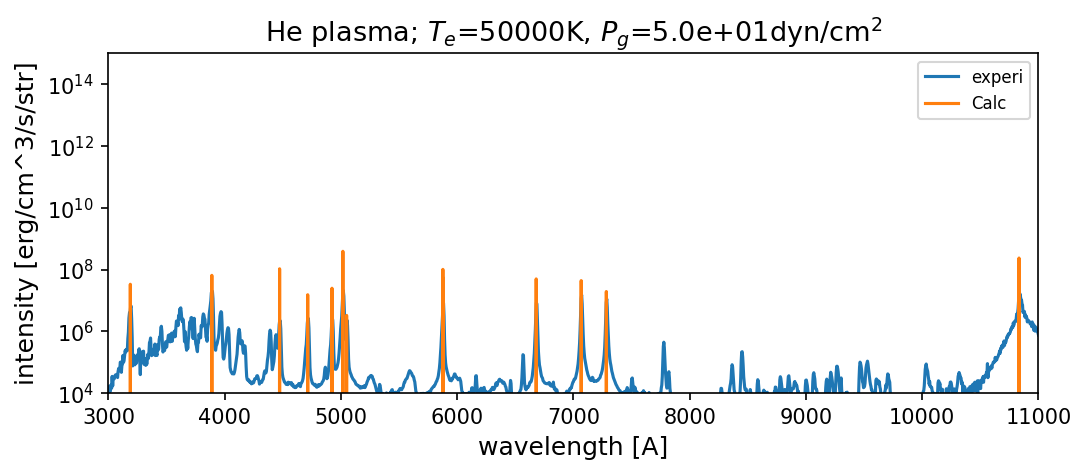

In [13]:
fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)


ax.plot(wlo,spo,label='experi')
ax.plot(lHe.wl_1D*1e8,lHe.prof_1D,'-',label='Calc')
#ax.set_ylim(1e9,1E14)
#ax.set_xlim(500, 50000)
#ax.set_xscale("log")
ax.set_xlim(3000, 11000)
ax.set_yscale("log")
ax.set_ylim(1e4, 1e15)
#ax.set_ylim(0, 6e7)
ax.set_xlabel("wavelength [A]", fontsize=12)
ax.set_ylabel("intensity [erg/cm^3/s/str]", fontsize=12)
plt.title("He plasma; $T_e$={0:5.0f}K, $P_g$={1:5.1e}dyn/cm$^{{2}}$".format(Te, Pg),fontsize=13)
ax.legend(fontsize=8,ncol=1)
plt.show()

In [10]:
atom_He.Line['w0_AA'][0]

625.5629940686423

In [74]:
#for i in 
atom = atom_He
l = line_list(atom)

id   wavelength[A]  Aji[s-1]   lower level ctj    -     upper level ctj 
193      256.32  3.0E+09    ('1s', '2S', '1/2')  -  ('3p', '2P', '1/2+3/2')
191      303.78  1.0E+10    ('1s', '2S', '1/2')  -  ('2p', '2P', '1/2+3/2')
 13      537.03  5.9E+08    ('1s2', '1S', '0')  -  ('1s.3p', '1P', '1')
  5      584.33  1.8E+09    ('1s2', '1S', '0')  -  ('1s.2p', '1P', '1')
197     1640.36  3.0E+09    ('2s', '2S', '1/2')  -  ('3p', '2P', '1/2+3/2')
200     1640.45  1.0E+09    ('2p', '2P', '1/2+3/2')  -  ('3p', '2P', '1/2+3/2')
199     1640.48  1.0E+08    ('2p', '2P', '1/2+3/2')  -  ('3s', '2S', '1/2')
 34     3188.66  7.2E+06    ('1s.2s', '3S', '1')  -  ('1s.4p', '3P', '2+1+0')
 26     3889.74  1.0E+07    ('1s.2s', '3S', '1')  -  ('1s.3p', '3P', '2+1+0')
 68     4472.73  3.1E+07    ('1s.2p', '3P', '2')  -  ('1s.4d', '3D', '3+2+1')
 65     4714.46  1.6E+07    ('1s.2p', '3P', '2')  -  ('1s.4s', '3S', '1')
111     4923.30  2.7E+07    ('1s.2p', '1P', '1')  -  ('1s.4d', '1D', '2')
 48     5017.08  

dict_keys(['wl', 'pr', 'sp50w'])
